In [ ]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_34_.csv') 

In [12]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import torch
import os, os.path

class ClothDataset(Dataset):
    """
    Dataset con ANCHORING: cada muestra incluye las posiciones del frame 0
    (ancla fija) junto con las posiciones actuales y el SDF del frame t.
    
    Entrada por vértice: [x_anc, y_anc, z_anc,  <- posición anclada (frame 0)
                          x_t,   y_t,   z_t,    <- posición actual (frame t)
                          sdf_t]                 <- distancia a la esfera
    Total features por vértice: 7
    """
    def __init__(self, csv_data, num_vertices=6):
        self.data = csv_data
        self.data.columns = self.data.columns.str.strip()
        self.num_vertices = num_vertices

        self.position_prefixes = ['x', 'y', 'z']

        # Posiciones de salida (frame t+1): columnas x0..z5
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')
        # Quitamos primera fila de outputs (no es output de nada)
        # y última fila de input (no tiene output)
        self.output_positions = self.output_positions.iloc[1:]
        self.data = self.data.iloc[:-1]

        # Ancla: posiciones del frame 0 (primera fila de self.data)
        anchor_row = self.data.iloc[0]
        self.anchor = []
        for i in range(self.num_vertices):
            vtx_cols = [f"{p}{i}" for p in self.position_prefixes]
            self.anchor.append(anchor_row[vtx_cols].values.astype('float32'))
        # shape: (num_vertices, 3) como tensor fijo
        self.anchor_tensor = torch.tensor(self.anchor)  # (V, 3)

    def __len__(self):
        return len(self.data)

    def num_features(self):
        # 3 (ancla) + 3 (pos actual) + 1 (sdf) = 7
        return 7

    def num_vertex(self):
        return self.num_vertices

    def _get_frame_output_tensor(self, idx):
        """Posiciones absolutas en t+1 — target del modelo."""
        row = self.output_positions.iloc[idx]
        frame_data = []
        for i in range(self.num_vertices):
            vtx_cols = [f"{p}{i}" for p in self.position_prefixes]
            frame_data.append(row[vtx_cols].values.astype('float32'))
        return torch.tensor(frame_data)  # (V, 3)

    def _get_frame_tensor(self, idx):
        """
        Construye el tensor de entrada con anchoring:
          [x_anc, y_anc, z_anc, x_t, y_t, z_t, sdf_t]  para cada vértice.
        """
        row = self.data.iloc[idx]
        frame_data = []
        for i in range(self.num_vertices):
            # Posición actual
            pos_t = row[[f"x{i}", f"y{i}", f"z{i}"]].values.astype('float32')
            # SDF actual
            sdf_t = row[f"sdf{i}"].astype('float32').reshape(1)
            # Ancla (frame 0, fija durante toda la simulación)
            anc = self.anchor[i]  # (3,)
            # Concatenar: [anc_xyz | pos_t_xyz | sdf_t]  → 7 features
            vertex_features = np.concatenate([anc, pos_t, sdf_t])
            frame_data.append(vertex_features)
        return torch.tensor(frame_data)  # (V, 7)

    def __getitem__(self, idx):
        frame_t = self._get_frame_tensor(idx)      # (V, 7)
        frame_t1 = self._get_frame_output_tensor(idx)  # (V, 3)
        return frame_t, frame_t1

# --- Uso ---
dataset = ClothDataset(df)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print(f"Num features por vértice: {dataset.num_features()}  (3 ancla + 3 pos + 1 sdf)")
for batch_data, batch_frames in dataloader:
    print(f"Input shape:  {batch_data.shape}")   # (B, V, 7)
    print(f"Target shape: {batch_frames.shape}") # (B, V, 3)
    break


Num features por vértice: 7  (3 ancla + 3 pos + 1 sdf)
Input shape:  torch.Size([4, 6, 7])
Target shape: torch.Size([4, 6, 3])


In [13]:
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

class MyModule(nn.Module):
    """
    Red neuronal con anchoring.
    Entrada: (Batch, V, 7)  → [pos_ancla_xyz | pos_t_xyz | sdf_t]
    Salida:  (Batch, V, 3)  → desplazamiento Δ predicho (se suma a pos_t para obtener pos_t+1)
    
    Gracias al anchoring la red puede comparar explícitamente la posición
    actual con la posición de reposo, lo que elimina la deriva acumulativa:
    en inferencia la ancla NUNCA cambia, aunque las posiciones actuales
    provengan de predicciones anteriores.
    """
    def __init__(self, num_verts=6, num_feats=7):
        super().__init__()
        self.input_dim  = num_verts * num_feats   # 6*7 = 42
        self.output_dim = num_verts * 3            # 6*3 = 18

        self.net = nn.Sequential(
            nn.Linear(self.input_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, self.output_dim)
        )

    def forward(self, x):
        # x: (Batch, V, 7)
        x = x.view(x.size(0), -1)   # (Batch, 42)
        x = self.net(x)
        return x.view(x.size(0), -1, 3)  # (Batch, V, 3)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np
import json

NUM_FEATS = 7  # 3 ancla + 3 pos_t + 1 sdf

# --- Dataloaders ---
train_dataset = dataset
test_dataset  = dataset

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False)

# --- Estadísticas globales de normalización ---
all_inputs  = []
all_targets = []

for batch_t, batch_t1 in dataloader:
    # batch_t: (B, V, 7)
    all_inputs.append(batch_t.view(-1, NUM_FEATS))

    pos_t  = batch_t[..., 3:6]   # posición actual está en canales 3-5
    delta  = batch_t1 - pos_t
    all_targets.append(delta.view(-1, 3))

full_input_tensor  = torch.cat(all_inputs,  dim=0)
full_target_tensor = torch.cat(all_targets, dim=0)

input_mean  = full_input_tensor.mean(dim=0)
input_std   = full_input_tensor.std(dim=0)
target_mean = full_target_tensor.mean(dim=0)
target_std  = full_target_tensor.std(dim=0)

# Evitar división por cero en canales con std ≈ 0
input_std  = input_std.clamp(min=1e-8)
target_std = target_std.clamp(min=1e-8)

norm_data = {
    "mean":        input_mean.tolist(),
    "std":         input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std":  target_std.tolist()
}
with open("cloth_norm_params_anchored.json", "w") as f:
    json.dump(norm_data, f)
print("Norm params guardados en cloth_norm_params.json")

# --- Modelo, loss y optimizador ---
model     = MyModule(num_verts=6, num_feats=NUM_FEATS)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
print("Inicio del entrenamiento (anchoring activado)...")

# --- Bucle de entrenamiento ---
epochs = 50

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for batch_t, batch_t1 in train_loader:
        batch_t  = batch_t.float()
        batch_t1 = batch_t1.float()

        # Normalizar entrada (7 features por vértice)
        batch_t_norm = (batch_t - input_mean) / input_std

        # Target: desplazamiento Δ = pos_{t+1} - pos_t
        # La posición actual está en los canales 3,4,5 del input
        pos_t             = batch_t[..., 3:6]
        target_delta      = batch_t1 - pos_t
        target_delta_norm = (target_delta - target_mean) / target_std

        pred_delta_norm = model(batch_t_norm)
        loss = criterion(pred_delta_norm, target_delta_norm)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # TEST / VALIDACIÓN
    model.eval()
    test_loss            = 0.0
    total_distance_error = 0.0
    total_vertices       = 0
    all_pred_deltas      = []
    all_target_deltas    = []

    with torch.no_grad():
        for batch_t, batch_t1 in test_loader:
            batch_t, batch_t1 = batch_t.float(), batch_t1.float()

            batch_t_norm = (batch_t - input_mean) / input_std
            pred_delta_norm = model(batch_t_norm)

            pos_t             = batch_t[..., 3:6]
            target_delta      = batch_t1 - pos_t
            target_delta_norm = (target_delta - target_mean) / target_std

            loss = criterion(pred_delta_norm, target_delta_norm)
            test_loss += loss.item()

            # Desnormalizar para métricas en metros
            pred_delta_meters = pred_delta_norm * target_std + target_mean

            distances = torch.norm(pred_delta_meters - target_delta, dim=-1)
            total_distance_error += distances.sum().item()
            total_vertices       += distances.numel()

            all_pred_deltas.append(pred_delta_meters.cpu().numpy())
            all_target_deltas.append(target_delta.cpu().numpy())

    avg_test_loss      = test_loss  / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    print(f'Epoch {epoch+1:03d} | Train: {avg_train_loss:.6f} | Test: {avg_test_loss:.6f} | Vertex Err: {avg_distance_error:.6f} m')

# Arrays finales para visualización
preds_pos_np   = np.concatenate(all_pred_deltas,  axis=0)
targets_pos_np = np.concatenate(all_target_deltas, axis=0)


Norm params guardados en cloth_norm_params.json
Inicio del entrenamiento (anchoring activado)...
Epoch 001 | Train: 0.558045 | Test: 0.553341 | Vertex Err: 0.023485 m
Epoch 002 | Train: 0.552833 | Test: 0.549014 | Vertex Err: 0.023285 m
Epoch 003 | Train: 0.545863 | Test: 0.536272 | Vertex Err: 0.022774 m
Epoch 004 | Train: 0.529100 | Test: 0.511040 | Vertex Err: 0.021694 m
Epoch 005 | Train: 0.505432 | Test: 0.492313 | Vertex Err: 0.020432 m
Epoch 006 | Train: 0.477178 | Test: 0.468570 | Vertex Err: 0.019353 m
Epoch 007 | Train: 0.459289 | Test: 0.438789 | Vertex Err: 0.017761 m
Epoch 008 | Train: 0.443406 | Test: 0.429825 | Vertex Err: 0.017052 m
Epoch 009 | Train: 0.430809 | Test: 0.423512 | Vertex Err: 0.016797 m
Epoch 010 | Train: 0.418842 | Test: 0.420832 | Vertex Err: 0.016901 m
Epoch 011 | Train: 0.408142 | Test: 0.413872 | Vertex Err: 0.016731 m
Epoch 012 | Train: 0.398256 | Test: 0.388610 | Vertex Err: 0.014897 m
Epoch 013 | Train: 0.393078 | Test: 0.381487 | Vertex Err: 0.01

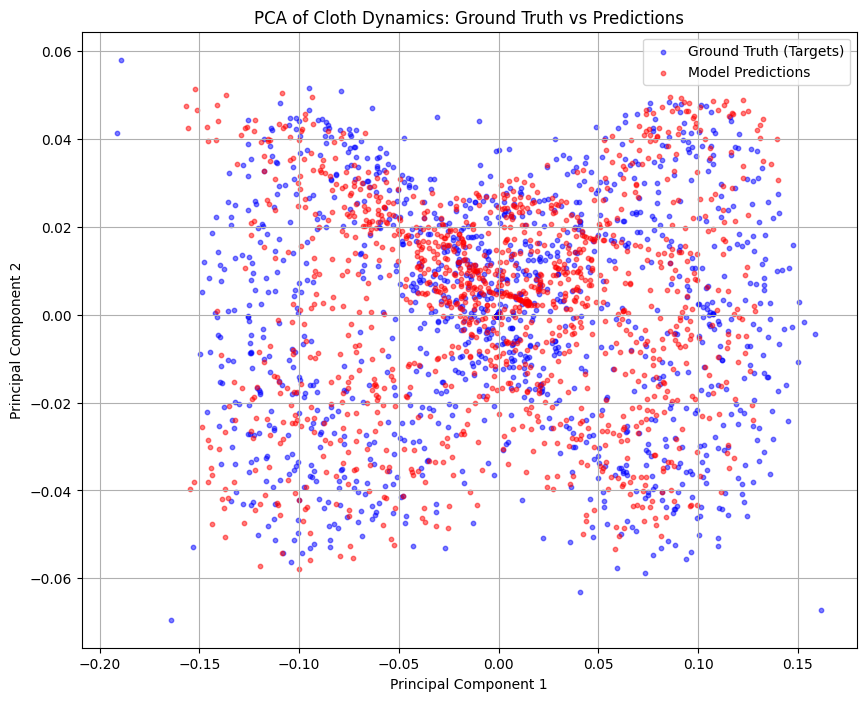

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

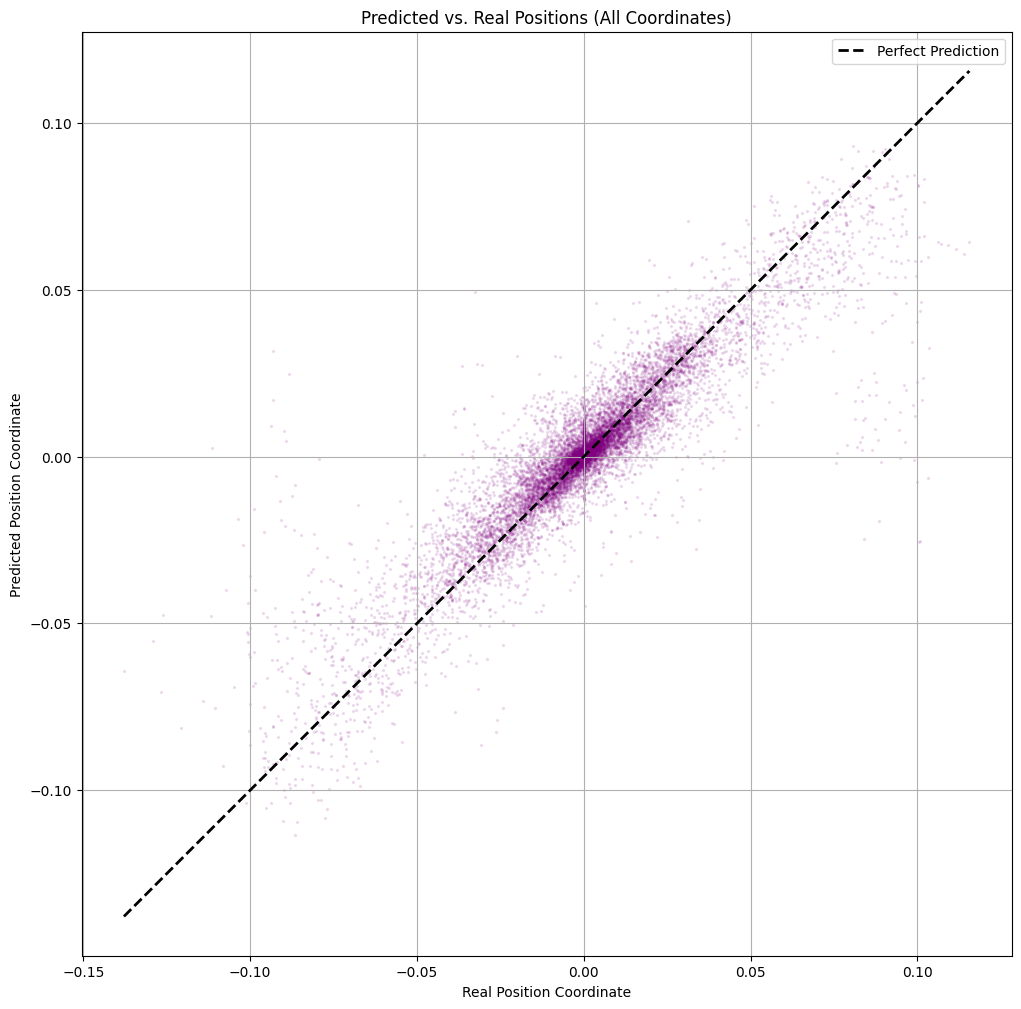

In [16]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

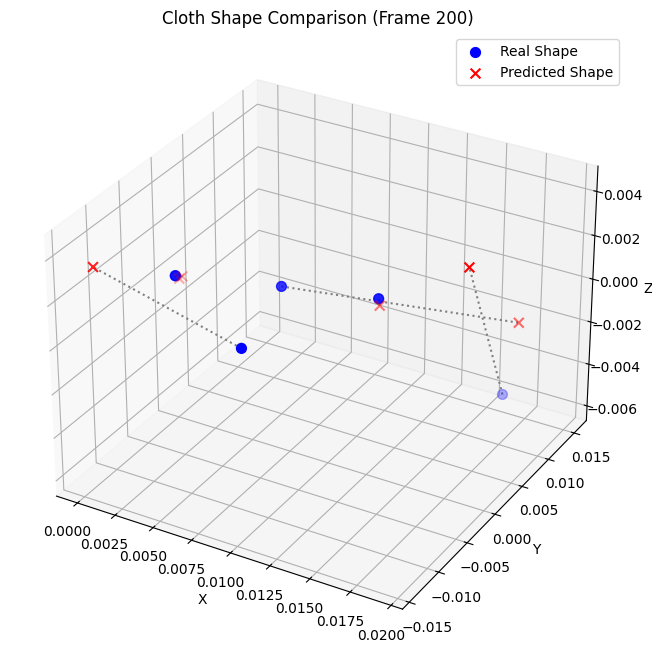

In [17]:
# Choose a random frame from your test set to visualize
frame_idx = 200# Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [18]:
import torch
import sys
import onnx
import onnxruntime

model.eval()

# Input: (Batch=1, Vertices=6, Features=7)  ← 7 = 3 ancla + 3 pos_t + 1 sdf
dummy_input = torch.randn(1, 6, 7)

onnx_program = torch.onnx.export(
    model,
    dummy_input,
    "cloth_anchoring.onnx",
    export_params=True,
    opset_version=9,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print("Exportado a cloth_anchoring.onnx")
print("Input shape en Unity: (batch, 6, 7)  — recordar pasar [anc_xyz | pos_t_xyz | sdf_t] por vértice")


Exportado a cloth_anchoring.onnx
Input shape en Unity: (batch, 6, 7)  — recordar pasar [anc_xyz | pos_t_xyz | sdf_t] por vértice
